# DGCNN for DGUHA

DGUHA is made of 7 categories.

We write the dimensions as:
- T: time frames, set to 400 by DGUHA preprocessing
- D: radar coordinate features, x/y/z
- N: radar points per frame, set to 25 
- B: batches

Among the N dimension, there is invariance by permutation because point order does not matter. To achieve this token permutation invariance, max pooling is added. Across the time dimension, position is important, so attention is applied along time.

In [1]:
from functools import lru_cache
from pathlib import Path
import pickle
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from IPython.display import clear_output
from torch.utils.data import DataLoader, Dataset

In [2]:
PROJECT_ROOT = Path('/Users/elo/Coding/radar')
DATA_ROOT = PROJECT_ROOT / 'datasets' / 'DGUHA'
CHECKPOINT_ROOT = PROJECT_ROOT / 'checkpoints' / 'DGUHA_dgcnn'

TRAIN_POINTS_FILE = DATA_ROOT / 'Train' / 'dguha_pcl_ahc_train.npy'
TEST_POINTS_FILE = DATA_ROOT / 'Test' / 'dguha_pcl_ahc_test.npy'
TRAIN_LABEL_FILE = DATA_ROOT / 'Train' / 'dguha_train_label.pkl'
TEST_LABEL_FILE = DATA_ROOT / 'Test' / 'dguha_test_label.pkl'

SEED = 1234
DEVICE = "mps"
ACTIVITY_CLASS_NAMES = (
    'running', 'jumping', 'sitting_down_and_standing_up', 'both_upper_limb_extension', 
    'falling_forward', 'right_limb_extension','left_limb_extension'
)

CONFIG = {
    'feature_names': ('x', 'y', 'z'),
    'feature_amount': 3,
    'frame_count': 400,
    'points_per_frame': 25,
    'validation_fraction': 0.2,
    'clipping': 4.0,
    'batch_size': 8,
    'dropout_rate': 0.5,
    'emb_dims': 1024,
    'k': 20,
    "num_epochs": 10,
    "base_lr": 1e-3,
    "lr_warmup_epochs": 5,
    "adam_momentum": 0.9,
    "accum_iter": 1,
}

torch.manual_seed(SEED)

# Data

In [3]:
@lru_cache(maxsize=None)
def load_dataset(split):
    "Load DGUHA points and labels."
    points_file = TRAIN_POINTS_FILE if split == 'train' else TEST_POINTS_FILE
    label_file = TRAIN_LABEL_FILE if split == 'train' else TEST_LABEL_FILE
    points = np.load(points_file, mmap_mode='r')[:, :, :, :, 0]
    points = np.asarray(points, dtype=np.float32).transpose(0, 2, 3, 1)
    with open(label_file, 'rb') as file:
        labels = pickle.load(file)
    return torch.from_numpy(points), torch.tensor(labels, dtype=torch.long)

In [4]:
@lru_cache(maxsize=None)
def validation_split():
    "Split DGUHA train clips into train and validation samples."
    _, labels = load_dataset('train')
    train_samples = [('train', idx, int(label)) for idx, label in enumerate(labels)]
    train_split, valid_split = [], []
    for class_idx in range(len(ACTIVITY_CLASS_NAMES)):
        class_samples = [sample for sample in train_samples if sample[2] == class_idx]
        order = torch.randperm(len(class_samples)).tolist()
        valid_count = int(len(class_samples) * CONFIG['validation_fraction'])
        valid_split.extend(class_samples[idx] for idx in order[:valid_count]) # first N frames of the random choice
        train_split.extend(class_samples[idx] for idx in order[valid_count:])
    return train_split, valid_split

In [5]:
@lru_cache(maxsize=None)
def statistics():
    "Compute normalization stats from train dataset."
    train_samples, _ = validation_split()  # only get stats from the train dataset to prevent overfitting to val or test
    points, _ = load_dataset('train')
    train_points = torch.stack([points[sample_idx] for _, sample_idx, _ in train_samples])
    point_mask = train_points.ne(0).any(dim=-1)
    valid_points = train_points[point_mask]
    return valid_points.mean(dim=0), valid_points.std(dim=0)

print(statistics())

(tensor([0.9610, 0.1283, 0.1473]), tensor([0.9528, 0.3932, 0.5171]))


In [6]:
@lru_cache(maxsize=None)
def normalize(points):
    "Normalize DGUHA xyz coordinates with train-set statistics, and clip outliers."
    mean, std = statistics()
    return ((points - mean) / std).clamp(-CONFIG['clipping'], CONFIG['clipping'])

In [7]:
def augmentation(sequence):
    "Apply one DGCNN-style spatial transform to a training sequence."
    scale = torch.empty(3).uniform_(0.5, 1.5)
    shift = torch.empty(3).uniform_(-0.5, 0.5)
    jitter = torch.randn_like(sequence[:, :, :3]) * 0.01 # gaussian noise
    point_mask = sequence.ne(0).any(dim=-1, keepdim=True)
    sequence = sequence.clone()
    sequence[:, :, :3] = sequence[:, :, :3] * scale + shift + jitter
    return sequence * point_mask

In [8]:
class DGUHADataset(Dataset):
    "Dataset containing full DGUHA radar point-cloud clips."
    def __init__(self, samples, augment=False):
        self.samples = samples
        self.augment = augment

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        split, sample_idx, label_idx = self.samples[idx]
        points, _ = load_dataset(split)
        sequence = normalize(points[sample_idx])
        if self.augment:  # if training data, we augment it
            sequence = augmentation(sequence)
        label = torch.tensor(label_idx, dtype=torch.long)
        return sequence, label

In [9]:
_, labels = load_dataset('train')
all_windows = [('train', idx, int(label)) for idx, label in enumerate(labels)]
train_windows, valid_windows = validation_split()
print('total windows:', len(all_windows))
print(f'Train windows: {len(train_windows)} | Validation: {len(valid_windows)}')
print(ACTIVITY_CLASS_NAMES)

train_points, train_labels = load_dataset('train')
print(train_points.shape) # (W, B, N, D)
print('distribution:', torch.bincount(train_labels, minlength=len(ACTIVITY_CLASS_NAMES))) # very balanced dataset
processed_frame = normalize(train_points[0, 0])
print(processed_frame.shape)

train_data = DGUHADataset(train_windows, augment=True)
print(len(train_data))
x, y = train_data[0]
print(x.shape, y)

train_samples, valid_samples = validation_split()
print(f'Train windows: {len(train_samples)}')
print(f'Validation windows: {len(valid_samples)}')
train_dataset = DGUHADataset(train_samples, augment=True)
train_dataloader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, drop_last=True)
sample_batch, sample_labels = next(iter(train_dataloader))
print(f'Input shape: {sample_batch.shape}') # x: (B, T, N, D)
print(f'Label shape: {sample_labels.shape}') 

total windows: 607
Train windows: 488 | Validation: 119
('running', 'jumping', 'sitting_down_and_standing_up', 'both_upper_limb_extension', 'falling_forward', 'right_limb_extension', 'left_limb_extension')
torch.Size([607, 400, 25, 3])
distribution: tensor([87, 86, 86, 87, 87, 87, 87])
torch.Size([25, 3])
488
torch.Size([400, 25, 3]) tensor(0)
Train windows: 488
Validation windows: 119
Input shape: torch.Size([8, 400, 25, 3])
Label shape: torch.Size([8])


# architecture

In [10]:
def knn(x, k):
    "Find each point's k nearest neighbors."
    inner = -2 * torch.matmul(x.transpose(2, 1), x)
    xx = torch.sum(x ** 2, dim=1, keepdim=True)
    pairwise_distance = -xx - inner - xx.transpose(2, 1)
    return pairwise_distance.topk(k=k, dim=-1)[1]

In [11]:
def get_graph_feature(x, k=20):
    "Build EdgeConv features as concatenated neighbor offsets and point features."
    batch_size, feature_amount, point_amount = x.shape
    idx = knn(x, k=k)
    idx_base = torch.arange(batch_size, device=x.device).view(-1, 1, 1) * point_amount
    idx = (idx + idx_base).view(-1)
    points = x.transpose(2, 1).contiguous()
    neighbors = points.view(batch_size * point_amount, feature_amount)[idx]
    neighbors = neighbors.view(batch_size, point_amount, k, feature_amount)
    points = points.view(batch_size, point_amount, 1, feature_amount).repeat(1, 1, k, 1)
    return torch.cat((neighbors - points, points), dim=3).permute(0, 3, 1, 2).contiguous()

In [12]:
class DGCNN(nn.Module):
    "DGCNN classifier applied per radar frame, with temporal mean aggregation."
    def __init__(self, feature_amount):
        super().__init__()
        self.k = CONFIG['k']
        self.conv1 = nn.Sequential(nn.Conv2d(feature_amount * 2, 64, 1, bias=False), nn.BatchNorm2d(64), nn.LeakyReLU(0.2))
        self.conv2 = nn.Sequential(nn.Conv2d(128, 64, 1, bias=False), nn.BatchNorm2d(64), nn.LeakyReLU(0.2))
        self.conv3 = nn.Sequential(nn.Conv2d(128, 128, 1, bias=False), nn.BatchNorm2d(128), nn.LeakyReLU(0.2))
        self.conv4 = nn.Sequential(nn.Conv2d(256, 256, 1, bias=False), nn.BatchNorm2d(256), nn.LeakyReLU(0.2))
        self.conv5 = nn.Sequential(nn.Conv1d(512, CONFIG['emb_dims'], 1, bias=False), nn.BatchNorm1d(CONFIG['emb_dims']), nn.LeakyReLU(0.2))
        self.linear1 = nn.Linear(CONFIG['emb_dims'] * 2, 512, bias=False)
        self.bn6 = nn.BatchNorm1d(512)
        self.dropout1 = nn.Dropout(CONFIG['dropout_rate'])
        self.linear2 = nn.Linear(512, 256)
        self.bn7 = nn.BatchNorm1d(256)
        self.dropout2 = nn.Dropout(CONFIG['dropout_rate'])
        self.linear3 = nn.Linear(256, len(ACTIVITY_CLASS_NAMES))

    def forward(self, x):
        batch_size, frame_count, point_amount, feature_amount = x.shape
        x = x.view(batch_size * frame_count, point_amount, feature_amount).permute(0, 2, 1)
        x1 = self.conv1(get_graph_feature(x, self.k)).max(dim=-1)[0]
        x2 = self.conv2(get_graph_feature(x1, self.k)).max(dim=-1)[0]
        x3 = self.conv3(get_graph_feature(x2, self.k)).max(dim=-1)[0]
        x4 = self.conv4(get_graph_feature(x3, self.k)).max(dim=-1)[0]
        x = self.conv5(torch.cat((x1, x2, x3, x4), dim=1))
        x = torch.cat((F.adaptive_max_pool1d(x, 1).view(batch_size * frame_count, -1), F.adaptive_avg_pool1d(x, 1).view(batch_size * frame_count, -1)), dim=1)
        x = F.leaky_relu(self.bn6(self.linear1(x)), negative_slope=0.2)
        x = self.dropout1(x)
        x = F.leaky_relu(self.bn7(self.linear2(x)), negative_slope=0.2)
        x = self.dropout2(x)
        x = self.linear3(x).view(batch_size, frame_count, -1)
        return x.mean(dim=1)

In [13]:
train_samples, valid_samples = validation_split()
print(f'Train windows: {len(train_samples)}')
print(f'Validation windows: {len(valid_samples)}')

train_dataset = DGUHADataset(train_samples, augment=True)
valid_dataset = DGUHADataset(valid_samples)
train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=CONFIG['batch_size'], shuffle=False)

Train windows: 488
Validation windows: 119


In [14]:
model = DGCNN(CONFIG["feature_amount"])

sample_batch, sample_labels = next(iter(train_loader))
print(f'Input shape: {sample_batch.shape}')
print(f'Label shape: {sample_labels.shape}')
output = model(sample_batch)
print(f'Output shape: {output.shape}')

Input shape: torch.Size([8, 400, 25, 3])
Label shape: torch.Size([8])
Output shape: torch.Size([8, 7])


# training

In [15]:
def create_dataloaders(batch_size):
    "Create train and validation dataloaders."
    train_samples, valid_samples = validation_split()
    train_dataset = DGUHADataset(train_samples, augment=True)
    valid_dataset = DGUHADataset(valid_samples)
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    valid_dataloader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, drop_last=False)
    return train_dataloader, valid_dataloader

In [16]:
def learning_rate(epoch, base, warmup=5):
    epoch = max(epoch, 1)
    return base * min(epoch ** (-0.5), epoch * warmup ** (-1.5))

In [17]:
def smoothing(pred, targets, smoothing=0.2):
    "The true class becomes 1-smoothing, and the rest of the probability is distributed amongst the other classes"
    targets = targets.contiguous().view(-1)
    class_amount = pred.size(1)
    one_hot = torch.zeros_like(pred).scatter(1, targets.view(-1, 1), 1)
    one_hot = one_hot * (1 - smoothing) + (1 - one_hot) * smoothing / (class_amount - 1)
    log_prob = F.log_softmax(pred, dim=1)
    return -(one_hot * log_prob).sum(dim=1).mean()


In [18]:
class Loss:
    "Cross-entropy loss with label smoothing."
    def __call__(self, out, targets, batch_size):
        loss_node = smoothing(out, targets)
        loss = loss_node.detach() * batch_size
        return loss, loss_node


In [19]:
def run_epoch(data_iter, model, loss_compute, optimizer=None, mode="train", accum_iter=1):
    "Runs one epoch, either for training, either validation."
    start, device = time.time(), torch.device(DEVICE)
    total_tokens, total_loss, tokens, n_accum = 0, 0, 0, 0
    loss_list, grad_norms = [], []
    for i, (src, targets) in enumerate(data_iter):
        src, targets = src.to(device), targets.to(device)
        ntokens = targets.size(0)
        loss, loss_node = loss_compute(model.forward(src), targets, ntokens)

        if mode == "train":
            (loss_node / accum_iter).backward()
            if i % accum_iter == 0:
                if optimizer is not None:
                    norm = torch.nn.utils.clip_grad_norm_(model.parameters(), float("inf")).item()
                    grad_norms.append(norm)
                    optimizer.step(); optimizer.zero_grad(set_to_none=True)
                n_accum += 1
        total_loss += loss; total_tokens += ntokens; tokens += ntokens
        loss_list.append((loss / ntokens).item())
        if i % 40 == 1 and mode == "train":
            lr, elapsed = optimizer.param_groups[0]["lr"], time.time() - start
            print(
                ("Batch: %6d | Accum. Step: %3d | Loss: %6.2f " + "| Samples/sec: %7.1f | Learn. Rate: %6.1e")
                % (i, n_accum, loss / ntokens, tokens / elapsed, lr)
            )
            start, tokens = time.time(), 0

    return loss_list, grad_norms

In [20]:
def plot(train_losses, valid_losses, all_grad_norms, model_param_count, num_epochs, train_epoch_sizes, valid_epoch_sizes, epoch_means):
    "Plot the losses and the gradient norm over the training process."
    x_train = [e + i / s for e, s in enumerate(train_epoch_sizes) for i in range(s)]
    x_valid = [e + i / s for e, s in enumerate(valid_epoch_sizes) for i in range(s)]
    epoch_mean_valid_losses = [m for s, m in zip(valid_epoch_sizes, epoch_means) for _ in range(s)]
    tick_step = max(1, (num_epochs + 19) // 20)
    epoch_ticks = list(range(0, num_epochs + 1, tick_step))
    if epoch_ticks[-1] != num_epochs: epoch_ticks.append(num_epochs)
    plt.figure(figsize=(10, 10))
    ax1 = plt.subplot(2, 1, 1)
    w = max(1, int((len(train_losses) / num_epochs) * 0.1))
    train_loss_rolling = pd.Series(train_losses).rolling(window=w, center=True).mean()
    plt.plot(x_train, train_losses, label="Training Loss"); plt.plot(x_train, train_loss_rolling, label="Training Loss (Avg)", color="darkblue", linewidth=1); plt.plot(x_valid, valid_losses, label="Validation Loss", alpha=0.7); plt.plot(x_valid, epoch_mean_valid_losses, label="Val Loss (Avg)", color="red", linewidth=1, linestyle="--")
    plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend(); plt.title("Training and Validation Loss Over Epochs")
    ax1.set_xlim(0, num_epochs); ax1.set_xticks(epoch_ticks)
    y_min, y_max = ax1.get_ylim()
    best_mean_val = float("inf")
    for i, mean_val in enumerate(epoch_means):
        if mean_val <= best_mean_val and y_min <= mean_val <= y_max: ax1.text(i + 0.5, mean_val, f"{mean_val:.3g}", color="red", ha="center", va="bottom", fontweight="medium", clip_on=True)
        best_mean_val = min(best_mean_val, mean_val)
    ax = plt.subplot(2, 1, 2)
    plt.plot(x_train, all_grad_norms, label="Gradient Norm", color="orange"); plt.xlabel("Epochs"); plt.ylabel("Norm"); plt.legend(); plt.title("Gradient Norm over Epochs")
    ax.set_xlim(0, num_epochs); ax.set_xticks(epoch_ticks)
    ax.text(0.99, 0.02, f"Params count: {model_param_count:,}", transform=ax.transAxes, ha="right", va="bottom", fontsize=9, color="dimgray")
    plt.subplots_adjust(hspace=0.35); plt.show()

In [21]:
def train_model(num_epochs=CONFIG["num_epochs"]):
    "Launch the training process of a model."
    print("Training process starting...", flush=True)
    model = DGCNN(CONFIG["feature_amount"]).to(torch.device(DEVICE))
    model_param_count = sum(p.numel() for p in model.parameters())
    train_dataloader, valid_dataloader = create_dataloaders(batch_size=CONFIG["batch_size"])
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate(1, CONFIG["base_lr"], CONFIG["lr_warmup_epochs"]), betas=(CONFIG["adam_momentum"], 0.999))
    train_losses, valid_losses, all_grad_norms = [], [], []
    train_epoch_sizes, valid_epoch_sizes, epoch_means = [], [], []
    loss_compute, checkpoint_dir = Loss(), CHECKPOINT_ROOT
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    for epoch in range(num_epochs):
        epoch_lr = learning_rate(epoch + 1, CONFIG["base_lr"], CONFIG["lr_warmup_epochs"])
        for param_group in optimizer.param_groups: param_group["lr"] = epoch_lr
        model.train(); print(f"Epoch n°{epoch} Training ====", flush=True)
        loss_list, grad_norms = run_epoch(train_dataloader, model, loss_compute, optimizer, mode="train", accum_iter=CONFIG["accum_iter"])
        train_losses.extend(loss_list); train_epoch_sizes.append(len(loss_list)); all_grad_norms.extend(grad_norms)
        torch.save(model.state_dict(), checkpoint_dir / f"checkpoint_{epoch:02d}.pt")
        print(f"Epoch n°{epoch} Validation ====", flush=True); model.eval()
        with torch.no_grad():
            loss_list, _ = run_epoch(valid_dataloader, model, loss_compute, None, mode="eval")
        valid_losses.extend(loss_list); valid_epoch_sizes.append(len(loss_list))
        mean_val = sum(loss_list) / len(loss_list); epoch_means.append(mean_val)
        clear_output(wait=True)
        print("Training process starting...", flush=True); print(f"Epoch n°{epoch} complete | Validation loss: {mean_val:.4f}", flush=True)
        plot(train_losses, valid_losses, all_grad_norms, model_param_count, num_epochs, train_epoch_sizes, valid_epoch_sizes, epoch_means)

    return model

In [23]:
if __name__ == "__main__":
    train_model(50)

Training process starting...
Epoch n°0 Training ====
Batch:      1 | Accum. Step:   2 | Loss:   2.00 | Samples/sec:     0.9 | Learn. Rate: 8.9e-05


KeyboardInterrupt: 

# inference

In [ ]:
def compute_macro_f1(predictions, labels):
    scores = []
    for class_idx in range(len(ACTIVITY_CLASS_NAMES)):
        true_positive = ((predictions == class_idx) & (labels == class_idx)).sum().item()
        false_positive = ((predictions == class_idx) & (labels != class_idx)).sum().item()
        false_negative = ((predictions != class_idx) & (labels == class_idx)).sum().item()
        denominator = 2 * true_positive + false_positive + false_negative
        scores.append(0.0 if denominator == 0 else 2 * true_positive / denominator)
    return torch.tensor(scores, dtype=torch.float32)

In [ ]:
def compute_accuracy(predictions, labels):
    return (predictions == labels).float().mean().item()

In [ ]:
def evaluate_validation_checkpoint(checkpoint_path):
    "Score a checkpoint on validation only."
    device, model = torch.device(DEVICE), DGCNN(CONFIG['feature_amount']).to(DEVICE)
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()

    _, eval_samples = validation_split()
    eval_dataset = DGUHADataset(eval_samples)
    eval_loader = DataLoader(eval_dataset, batch_size=CONFIG['batch_size'], shuffle=False)

    all_predictions, all_labels = [], []
    with torch.no_grad():
        for batch, labels in eval_loader:
            all_predictions.append(model(batch.to(device)).argmax(dim=1).cpu())
            all_labels.append(labels.cpu())

    predictions, labels = torch.cat(all_predictions), torch.cat(all_labels)
    per_class_f1 = compute_macro_f1(predictions, labels)
    return per_class_f1.mean().item(), {name: float(score) for name, score in zip(ACTIVITY_CLASS_NAMES, per_class_f1)}, compute_accuracy(predictions, labels)

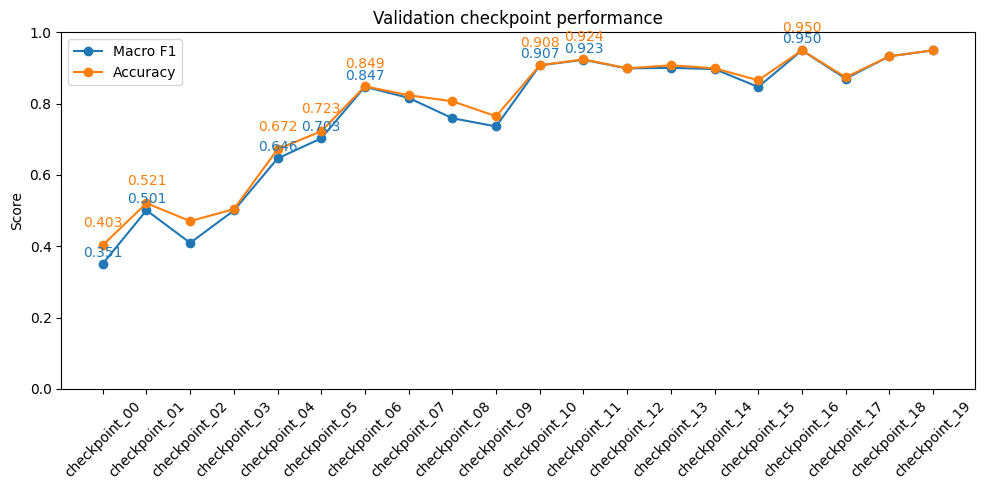

In [ ]:
checkpoint_paths = sorted(CHECKPOINT_ROOT.glob("checkpoint_*.pt"), key=lambda path: int(path.stem.split("_")[-1]))
metrics = [evaluate_validation_checkpoint(path) for path in checkpoint_paths]
checkpoint_numbers = [int(path.stem.split("_")[-1]) for path in checkpoint_paths]
checkpoint_labels = [path.stem for path in checkpoint_paths]
macro_f1_scores, accuracy_scores = ([metric[i] for metric in metrics] for i in (0, 2))

fig, ax = plt.subplots(figsize=(10, 5))
lines = [ax.plot(checkpoint_numbers, scores, marker="o", label=label)[0] for scores, label in ((macro_f1_scores, "Macro F1"), (accuracy_scores, "Accuracy"))]
for scores, line, offset in zip((macro_f1_scores, accuracy_scores), lines, (0.02, 0.05)):
    best = -1
    for checkpoint, score in zip(checkpoint_numbers, scores):
        if score > best:
            ax.text(checkpoint, score + offset, f"{score:.3f}", ha="center", color=line.get_color())
            best = score

tick_step = 1 if len(checkpoint_labels) <= 20 else max(2, (len(checkpoint_labels) + 14) // 15)
tick_indices = list(range(0, len(checkpoint_labels), tick_step))
ax.set_xticks([checkpoint_numbers[i] for i in tick_indices], [checkpoint_labels[i] for i in tick_indices], rotation=45, ha="right")
ax.set_xlim(checkpoint_numbers[0] - 0.5, checkpoint_numbers[-1] + 0.5); ax.set_ylim(min(macro_f1_scores + accuracy_scores) - 0.02, 1)
ax.set_xlabel("Checkpoint"); ax.set_ylabel("Score"); ax.set_title("Validation checkpoint performance")
ax.legend(); fig.tight_layout(); plt.show()

In [ ]:
best_idx = max(range(len(accuracy_scores)), key=lambda idx: (round(accuracy_scores[idx], 2), idx))
best_checkpoint_path = checkpoint_paths[best_idx]
device, model = torch.device(DEVICE), DGCNN(CONFIG['feature_amount']).to(DEVICE)
model.load_state_dict(torch.load(best_checkpoint_path, map_location=device))
model.eval()

_, labels = load_dataset('test')
eval_samples = [('test', idx, int(label)) for idx, label in enumerate(labels)]
eval_dataset = DGUHADataset(eval_samples)
eval_loader = DataLoader(eval_dataset, batch_size=CONFIG['batch_size'], shuffle=False)

all_predictions, all_labels = [], []
with torch.no_grad():
    for batch, labels in eval_loader:
        all_predictions.append(model(batch.to(device)).argmax(dim=1).cpu())
        all_labels.append(labels.cpu())

predictions, labels = torch.cat(all_predictions), torch.cat(all_labels)
per_class_f1 = compute_macro_f1(predictions, labels)
test_macro_f1, test_accuracy = per_class_f1.mean().item(), compute_accuracy(predictions, labels)
print(f'Best validation checkpoint: {best_checkpoint_path.name}')
print(f'Validation accuracy: {accuracy_scores[best_idx]:.4f}')
print(f'Test macro F1: {test_macro_f1:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')
print({name: float(score) for name, score in zip(ACTIVITY_CLASS_NAMES, per_class_f1)})

Best validation checkpoint: checkpoint_16.pt
Validation accuracy: 0.9496
Test macro F1: 0.8751
Test accuracy: 0.8758
{'running': 0.9166666865348816, 'jumping': 0.8636363744735718, 'sitting_down_and_standing_up': 0.95652174949646, 'both_upper_limb_extension': 0.7317073345184326, 'falling_forward': 1.0, 'right_limb_extension': 0.8500000238418579, 'left_limb_extension': 0.8070175647735596}
